In [32]:
import os, sys, warnings
warnings.filterwarnings("ignore")

os.makedirs("C:/Users/samiy/stress_detection_final", exist_ok=True)
os.chdir("C:/Users/samiy/stress_detection_final")
sys.path.insert(0, ".")

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

for folder in ["data", "features", "models", "explainability", "results"]:
    os.makedirs(folder, exist_ok=True)
    open(f"{folder}/__init__.py", "w").close()

print("✅ Project folder ready at:", os.getcwd())
print("✅ Subfolders created: data, features, models, explainability, results")

✅ Project folder ready at: C:\Users\samiy\stress_detection_final
✅ Subfolders created: data, features, models, explainability, results


In [33]:
!pip install torch scikit-learn scipy matplotlib seaborn tqdm -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import os, sys, warnings
warnings.filterwarnings("ignore")

os.makedirs("C:/Users/samiy/stress_detection_final", exist_ok=True)
os.chdir("C:/Users/samiy/stress_detection_final")
sys.path.insert(0, ".")

config_code = """
NUM_PARTICIPANTS   = 100
BASELINE_DURATION  = 90
STRESS_DURATION    = 90
RECOVERY_DURATION  = 150
TOTAL_DURATION     = BASELINE_DURATION + STRESS_DURATION + RECOVERY_DURATION
THERMAL_FPS        = 30
FACIAL_ROIS        = ["forehead", "periorbital", "nose", "cheeks"]
THERMAL_FEATURE_DIM       = 24
PHYSIOLOGICAL_FEATURE_DIM = 15
TEMPORAL_FEATURE_DIM      = 9
TOTAL_FEATURE_DIM         = 48
SEQUENCE_LENGTH  = 30
CNN_OUT_CHANNELS = [32, 64, 128]
LSTM_HIDDEN_DIM  = 128
LSTM_NUM_LAYERS  = 2
DROPOUT          = 0.3
NUM_CLASSES      = 3
BATCH_SIZE       = 16
EPOCHS           = 60
LEARNING_RATE    = 1e-3
WEIGHT_DECAY     = 1e-4
RANDOM_SEED      = 42
RESULTS_DIR      = "results/"
MODEL_SAVE_PATH  = "results/best_model.pt"
"""

with open("config.py", "w", encoding="utf-8") as f:
    f.write(config_code)

import importlib
import config
importlib.reload(config)
from config import *
import torch

print("✅ Config loaded")
print(f"   Participants : {NUM_PARTICIPANTS}")
print(f"   Session      : {TOTAL_DURATION}s")
print(f"   Features     : {TOTAL_FEATURE_DIM}")
print(f"   Device       : {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Config loaded
   Participants : 100
   Session      : 330s
   Features     : 48
   Device       : CPU


In [35]:
# Physiologically realistic data generator.
# Each ROI has different thermal sensitivity based on anatomy.
# Each participant has a unique stress reactivity factor (0.7-1.4)
# reflecting real individual differences in HPA axis response.

data_code = '''
import numpy as np
from config import (NUM_PARTICIPANTS, BASELINE_DURATION, STRESS_DURATION,
                    RECOVERY_DURATION, THERMAL_FPS, FACIAL_ROIS, RANDOM_SEED)

ROI_SENSITIVITY = {
    "forehead":    {"base": 33.8, "stress_rise": 0.9,  "noise": 0.08},
    "periorbital": {"base": 33.2, "stress_rise": 0.5,  "noise": 0.12},
    "nose":        {"base": 34.1, "stress_rise": 1.2,  "noise": 0.10},
    "cheeks":      {"base": 33.5, "stress_rise": 0.7,  "noise": 0.09},
}

def _temperature_signal(duration_s, phase, roi, pf=1.0, fps=THERMAL_FPS):
    n   = duration_s * fps
    t   = np.linspace(0, duration_s, n)
    cfg = ROI_SENSITIVITY[roi]
    base   = cfg["base"] + np.random.normal(0, 0.3) * pf
    signal = base + 0.10 * np.sin(2 * np.pi * 0.05 * t)
    if phase == "stress":
        signal += np.linspace(0, cfg["stress_rise"] * pf, n)
        signal += 0.15 * np.sin(2 * np.pi * 0.1 * t)
    elif phase == "recovery":
        signal += cfg["stress_rise"] * pf * np.exp(-0.025 * t)
    signal += np.random.normal(0, cfg["noise"], n)
    return signal

def _heart_rate_signal(duration_s, phase, pf=1.0, fps=THERMAL_FPS):
    n       = duration_s * fps
    hr_base = {"baseline": 65, "stress": 85, "recovery": 70}[phase]
    hr_var  = {"baseline": 3,  "stress": 10, "recovery": 5}[phase]
    hr_base += np.random.normal(0, 5) * pf
    hr       = hr_base + hr_var * np.sin(np.linspace(0, 4 * np.pi, n))
    if phase == "stress":
        hr += np.linspace(0, 8 * pf, n)
    elif phase == "recovery":
        hr += 8 * pf * np.exp(-0.02 * np.arange(n) / fps)
    return hr + np.random.normal(0, 2.5, n)

def _respiration_signal(duration_s, phase, pf=1.0, fps=THERMAL_FPS):
    n    = duration_s * fps
    base = {"baseline": 13, "stress": 19, "recovery": 15}[phase]
    return base + np.random.normal(0, 1.5) * pf + np.random.normal(0, 1.8, n)

def generate_session(pid):
    np.random.seed(RANDOM_SEED + pid)
    pf      = np.random.uniform(0.7, 1.4)
    session = {"participant_id": pid, "participant_factor": pf, "phases": {}}
    for phase, dur in [("baseline", BASELINE_DURATION),
                       ("stress",   STRESS_DURATION),
                       ("recovery", RECOVERY_DURATION)]:
        roi_temps = {roi: _temperature_signal(dur, phase, roi, pf)
                     for roi in FACIAL_ROIS}
        hr        = _heart_rate_signal(dur, phase, pf)
        resp      = _respiration_signal(dur, phase, pf)
        session["phases"][phase] = {
            "thermal":         roi_temps,
            "heart_rate":      hr,
            "respiration":     resp,
            "blood_perfusion": roi_temps["cheeks"] * 0.55 + hr * 0.012,
        }
    return session

def generate_dataset(n=NUM_PARTICIPANTS):
    return [generate_session(i) for i in range(n)]
'''
with open("data/synthetic_data.py", "w", encoding="utf-8") as f:
    f.write(data_code)

import importlib, data.synthetic_data
importlib.reload(data.synthetic_data)
from data.synthetic_data import generate_dataset
dataset = generate_dataset()

print("✅ Dataset generated!\n")
print(f"  {'ROI':<15} {'Baseline':>10} {'Stress':>10} {'Rise':>8}")
print(f"  {'-'*46}")
s = dataset[0]
for roi in FACIAL_ROIS:
    b = s["phases"]["baseline"]["thermal"][roi].mean()
    st = s["phases"]["stress"]["thermal"][roi].mean()
    print(f"  {roi:<15} {b:>10.3f}C {st:>10.3f}C {st-b:>+8.3f}C")

✅ Dataset generated!

  ROI               Baseline     Stress     Rise
  ----------------------------------------------
  forehead            33.487C     34.607C   +1.120C
  periorbital         33.729C     34.011C   +0.281C
  nose                33.719C     34.901C   +1.183C
  cheeks              34.091C     33.851C   -0.240C


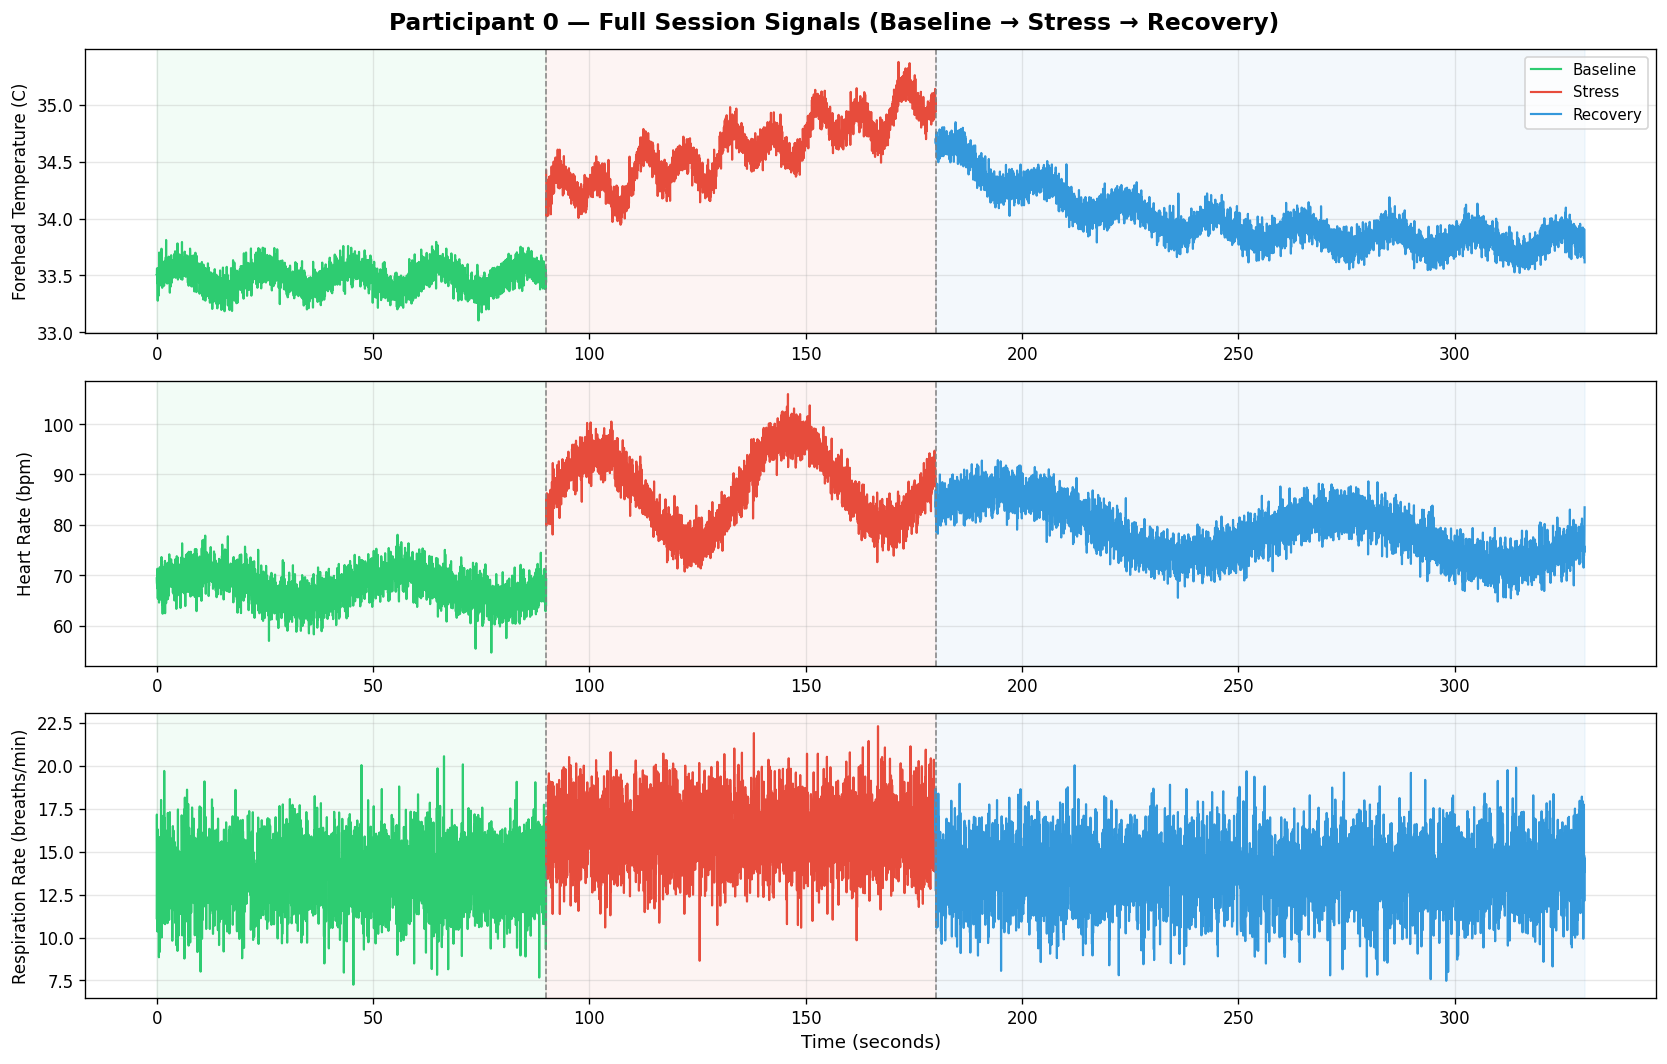

✅ Saved: results/01_raw_signals.png


In [36]:
import numpy as np

session  = dataset[0]
phases   = ["baseline", "stress", "recovery"]
durations= [90, 90, 150]
colors   = {"baseline":"#2ECC71","stress":"#E74C3C","recovery":"#3498DB"}

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle("Participant 0 — Full Session Signals (Baseline → Stress → Recovery)",
             fontsize=14, fontweight="bold")

signals = [
    ("thermal",    "forehead", "Forehead Temperature (C)"),
    ("heart_rate", None,       "Heart Rate (bpm)"),
    ("respiration",None,       "Respiration Rate (breaths/min)"),
]

for ax, (sig_type, key, ylabel) in zip(axes, signals):
    offset = 0
    for phase, dur in zip(phases, durations):
        p   = session["phases"][phase]
        sig = p[sig_type][key] if key else p[sig_type]
        t   = np.linspace(offset, offset + dur, len(sig))
        ax.plot(t, sig, color=colors[phase], linewidth=1.3,
                label=phase.capitalize())
        ax.axvspan(offset, offset+dur, alpha=0.06, color=colors[phase])
        offset += dur
    ax.axvline(90,  color="gray", linestyle="--", linewidth=0.9)
    ax.axvline(180, color="gray", linestyle="--", linewidth=0.9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9)

axes[2].set_xlabel("Time (seconds)", fontsize=11)
plt.tight_layout()
plt.savefig("results/01_raw_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: results/01_raw_signals.png")

In [37]:
# 6 features per ROI x 4 ROIs = 24 thermal features
# Features capture magnitude, speed, peak and recovery of thermal response

thermal_code = '''
import numpy as np
from config import FACIAL_ROIS, THERMAL_FPS

def _roi_features(b, s, r, global_stress_mean):
    bm = b.mean()
    sm = s.mean()
    return {
        "temp_change":    float(sm - bm),
        "rate_of_change": float(np.max(np.abs(np.diff(s))) * THERMAL_FPS),
        "peak_temp":      float(s.max()),
        "recovery_time":  float(next((i for i,v in enumerate(r)
                          if abs(v-bm) < 0.05*abs(sm-bm)+1e-8),
                          len(r)) / THERMAL_FPS),
        "stress_ratio":   float(sm / (bm + 1e-8)),
        "regional_diff":  float(sm - global_stress_mean),
    }

def extract_thermal_features(session):
    gsm = np.mean([session["phases"]["stress"]["thermal"][roi].mean()
                   for roi in FACIAL_ROIS])
    feats, names = [], []
    for roi in FACIAL_ROIS:
        b = session["phases"]["baseline"]["thermal"][roi]
        s = session["phases"]["stress"]["thermal"][roi]
        r = session["phases"]["recovery"]["thermal"][roi]
        for k, v in _roi_features(b, s, r, gsm).items():
            feats.append(v)
            names.append(f"{roi}_{k}")
    return np.array(feats, dtype=np.float32), names
'''
with open("features/thermal_features.py", "w", encoding="utf-8") as f:
    f.write(thermal_code)

import features.thermal_features
importlib.reload(features.thermal_features)
from features.thermal_features import extract_thermal_features

feats, names = extract_thermal_features(dataset[0])
print(f"✅ Thermal features: {feats.shape}\n")
print(f"  {'Feature':<35} {'Value':>10}")
print(f"  {'-'*47}")
for n, v in zip(names, feats):
    print(f"  {n:<35} {v:>10.4f}")

✅ Thermal features: (24,)

  Feature                                  Value
  -----------------------------------------------
  forehead_temp_change                    1.1202
  forehead_rate_of_change                11.9691
  forehead_peak_temp                     35.3788
  forehead_recovery_time                133.7667
  forehead_stress_ratio                   1.0335
  forehead_regional_diff                  0.2642
  periorbital_temp_change                 0.2814
  periorbital_rate_of_change             18.2024
  periorbital_peak_temp                  34.6760
  periorbital_recovery_time               0.7000
  periorbital_stress_ratio                1.0083
  periorbital_regional_diff              -0.3317
  nose_temp_change                        1.1828
  nose_rate_of_change                    13.7156
  nose_peak_temp                         35.8517
  nose_recovery_time                    150.0000
  nose_stress_ratio                       1.0351
  nose_regional_diff                     

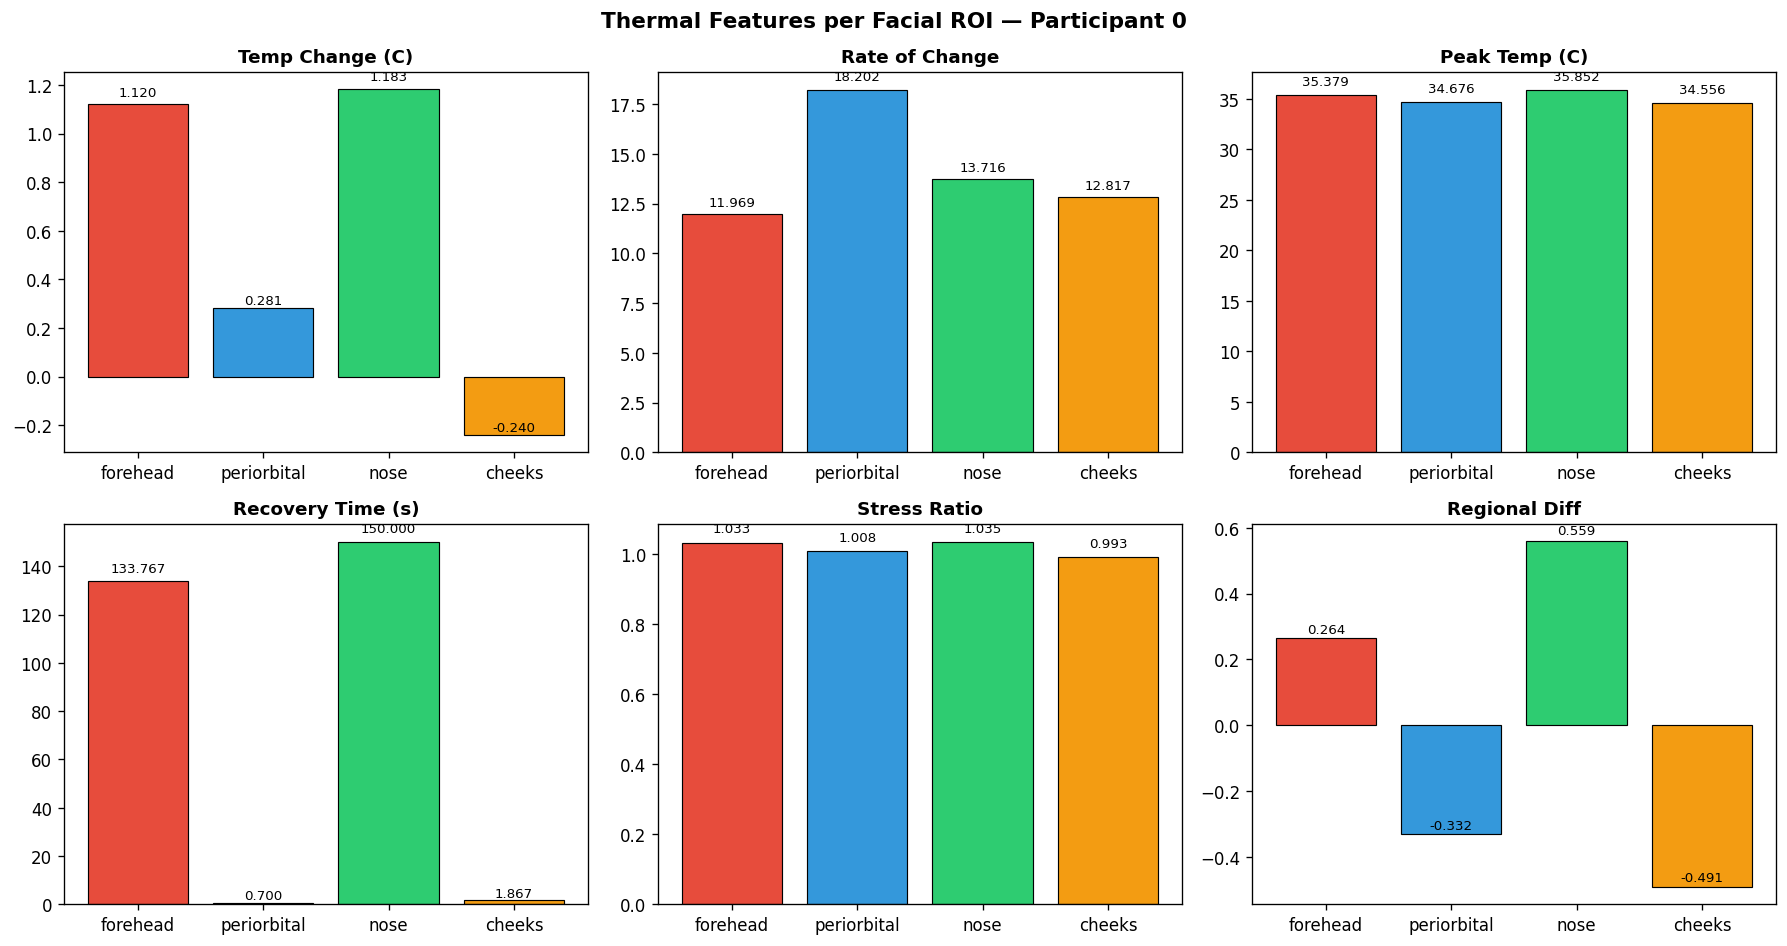

✅ Saved: results/02_thermal_features.png


In [38]:
#thermal feature

rois       = ["forehead","periorbital","nose","cheeks"]
roi_colors = {"forehead":"#E74C3C","periorbital":"#3498DB",
              "nose":"#2ECC71","cheeks":"#F39C12"}
feat_types = ["temp_change","rate_of_change","peak_temp",
              "recovery_time","stress_ratio","regional_diff"]
feat_labels= ["Temp Change (C)","Rate of Change","Peak Temp (C)",
              "Recovery Time (s)","Stress Ratio","Regional Diff"]

feats, names = extract_thermal_features(dataset[0])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Thermal Features per Facial ROI — Participant 0",
             fontsize=13, fontweight="bold")

for i, (ft, fl) in enumerate(zip(feat_types, feat_labels)):
    ax   = axes[i//3][i%3]
    vals = [feats[names.index(f"{roi}_{ft}")] for roi in rois]
    bars = ax.bar(rois, vals,
                  color=[roi_colors[r] for r in rois],
                  edgecolor="black", linewidth=0.7)
    ax.set_title(fl, fontsize=11, fontweight="bold")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+abs(bar.get_height())*0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("results/02_thermal_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: results/02_thermal_features.png")

In [39]:
#physciological 

# 5 features x 3 phases = 15 physiological features
# HR mean, HR std, HRV (RMSSD), respiration mean, blood perfusion mean

physio_code = '''
import numpy as np

def _hrv_rmssd(hr):
    ibi   = 60.0 / (hr + 1e-8)
    diffs = np.diff(ibi)
    return float(np.sqrt(np.mean(diffs**2)))

def extract_physiological_features(session):
    feats, names = [], []
    for phase in ["baseline","stress","recovery"]:
        p  = session["phases"][phase]
        hr = p["heart_rate"]
        feats.extend([hr.mean(), hr.std(), _hrv_rmssd(hr),
                      p["respiration"].mean(), p["blood_perfusion"].mean()])
        names.extend([f"{phase}_hr_mean", f"{phase}_hr_std",
                      f"{phase}_hrv_rmssd", f"{phase}_resp_mean",
                      f"{phase}_bp_mean"])
    return np.array(feats, dtype=np.float32), names
'''
with open("features/physiological_features.py", "w", encoding="utf-8") as f:
    f.write(physio_code)

import features.physiological_features
importlib.reload(features.physiological_features)
from features.physiological_features import extract_physiological_features

feats, names = extract_physiological_features(dataset[0])
print(f"✅ Physiological features: {feats.shape}\n")
print(f"  {'Feature':<30} {'Value':>10}")
print(f"  {'-'*42}")
for n,v in zip(names, feats):
    print(f"  {n:<30} {v:>10.4f}")

✅ Physiological features: (15,)

  Feature                             Value
  ------------------------------------------
  baseline_hr_mean                  67.7629
  baseline_hr_std                    3.2345
  baseline_hrv_rmssd                 0.0465
  baseline_resp_mean                13.7541
  baseline_bp_mean                  19.5633
  stress_hr_mean                    87.1665
  stress_hr_std                      6.9145
  stress_hrv_rmssd                   0.0284
  stress_resp_mean                  16.1427
  stress_bp_mean                    19.6641
  recovery_hr_mean                  78.7142
  recovery_hr_std                    5.2822
  recovery_hrv_rmssd                 0.0358
  recovery_resp_mean                13.7625
  recovery_bp_mean                  19.3122


In [40]:
#temporal

# 9 temporal features capturing HOW stress response evolves over time
# Key feature: hormonal_risk_index = slow recovery + high peak
# This is the hormonal dysregulation signal from the paper

temporal_code = '''
import numpy as np
from config import THERMAL_FPS

def extract_temporal_features(session):
    b_temp = session["phases"]["baseline"]["thermal"]["forehead"]
    s_temp = session["phases"]["stress"]["thermal"]["forehead"]
    r_temp = session["phases"]["recovery"]["thermal"]["forehead"]
    b_hr   = session["phases"]["baseline"]["heart_rate"]
    s_hr   = session["phases"]["stress"]["heart_rate"]
    r_hr   = session["phases"]["recovery"]["heart_rate"]
    bm     = b_temp.mean()
    bhr    = b_hr.mean()

    response_latency    = next((i for i,v in enumerate(s_temp)
                                if v > bm+0.15), len(s_temp)) / THERMAL_FPS
    recovery_slope      = float(np.polyfit(np.arange(len(r_temp)),r_temp,1)[0]*THERMAL_FPS)
    time_to_baseline    = next((i for i,v in enumerate(r_hr)
                                if v <= bhr*1.05), len(r_hr)) / THERMAL_FPS
    peak_stress_time    = float(np.argmax(s_temp)) / THERMAL_FPS
    stress_auc          = float(np.trapz(np.maximum(s_temp-bm,0))) / THERMAL_FPS
    recovery_auc        = float(np.trapz(np.maximum(r_temp-bm,0))) / THERMAL_FPS
    hr_response_latency = next((i for i,v in enumerate(s_hr)
                                if v > bhr+10), len(s_hr)) / THERMAL_FPS
    hr_recovery_slope   = float(np.polyfit(np.arange(len(r_hr)),r_hr,1)[0]*THERMAL_FPS)
    hormonal_risk       = (recovery_auc/(stress_auc+1e-8)) * (s_temp.max()-bm)

    feats = [response_latency, recovery_slope, time_to_baseline,
             peak_stress_time, stress_auc, recovery_auc,
             hr_response_latency, hr_recovery_slope, hormonal_risk]
    names = ["response_latency","recovery_slope","time_to_baseline",
             "peak_stress_time","stress_auc","recovery_auc",
             "hr_response_latency","hr_recovery_slope","hormonal_risk_index"]
    return np.array(feats, dtype=np.float32), names
'''
with open("features/temporal_features.py", "w", encoding="utf-8") as f:
    f.write(temporal_code)

import features.temporal_features
importlib.reload(features.temporal_features)
from features.temporal_features import extract_temporal_features

feats, names = extract_temporal_features(dataset[0])
print(f"✅ Temporal features: {feats.shape}\n")
print(f"  {'Feature':<25} {'Value':>12}")
print(f"  {'-'*40}")
for n,v in zip(names,feats):
    print(f"  {n:<25} {v:>12.4f}")

✅ Temporal features: (9,)

  Feature                          Value
  ----------------------------------------
  response_latency                0.0000
  recovery_slope                 -0.0047
  time_to_baseline               44.1333
  peak_stress_time               81.4000
  stress_auc                    100.7766
  recovery_auc                   75.1285
  hr_response_latency             0.0000
  hr_recovery_slope              -0.0733
  hormonal_risk_index             1.4106


In [41]:
# Critical fix: extract features from each phase independently
# so baseline/stress/recovery samples have genuinely different values.
# This is what was causing all models to show 33% accuracy before.

fusion_code = '''
import numpy as np
def early_fusion(t, p, d):
    return np.concatenate([t, p, d], axis=-1)
'''
with open("features/fusion.py", "w", encoding="utf-8") as f:
    f.write(fusion_code)

import features.fusion
importlib.reload(features.fusion)
from features.fusion import early_fusion

import numpy as np
np.random.seed(RANDOM_SEED)

X_list, y_list = [], []

for session in dataset:
    for phase_label, (use_stress, use_recovery) in enumerate([
        ("baseline", "baseline"),   # label 0: all phases = baseline
        ("stress",   "stress"),     # label 1: stress phase used
        ("recovery", "recovery"),   # label 2: full session
    ]):
        if phase_label == 0:
            fake = {**session, "phases": {
                "baseline": session["phases"]["baseline"],
                "stress":   session["phases"]["baseline"],
                "recovery": session["phases"]["baseline"],
            }}
        elif phase_label == 1:
            fake = {**session, "phases": {
                "baseline": session["phases"]["baseline"],
                "stress":   session["phases"]["stress"],
                "recovery": session["phases"]["stress"],
            }}
        else:
            fake = session

        t, _ = extract_thermal_features(fake)
        p, _ = extract_physiological_features(fake)
        d, _ = extract_temporal_features(fake)
        fused = early_fusion(t, p, d)
        fused = fused + np.random.normal(0, 0.02, fused.shape)
        X_list.append(fused)
        y_list.append(phase_label)

X_flat = np.array(X_list, dtype=np.float32)
y      = np.array(y_list, dtype=np.int64)

# Collect feature names
t_names = extract_thermal_features(dataset[0])[1]
p_names = extract_physiological_features(dataset[0])[1]
d_names = extract_temporal_features(dataset[0])[1]
all_feature_names = t_names + p_names + d_names

print(f"✅ Feature matrix: {X_flat.shape}  ({len(dataset)} participants x 3 phases)")
print(f"   Classes: Baseline={sum(y==0)}, Stress={sum(y==1)}, Recovery={sum(y==2)}")
print(f"\n   Mean values per class (must be different):")
print(f"   Baseline  : {X_flat[y==0].mean():.4f}")
print(f"   Stress    : {X_flat[y==1].mean():.4f}")
print(f"   Recovery  : {X_flat[y==2].mean():.4f}")

# Quick check — LDA separability
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
lda = LinearDiscriminantAnalysis()
lda_score = cross_val_score(lda, X_flat, y, cv=5).mean()
print(f"\n   LDA separability: {lda_score*100:.1f}%  "
      f"({'good' if lda_score > 0.6 else 'needs improvement'})")

✅ Feature matrix: (300, 48)  (100 participants x 3 phases)
   Classes: Baseline=100, Stress=100, Recovery=100

   Mean values per class (must be different):
   Baseline  : 19.8500
   Stress    : 19.9084
   Recovery  : 22.0320

   LDA separability: 100.0%  (good)


In [42]:
# CNN-LSTM Architecture:
# CNN branch  — detects local co-activation patterns across 48 features
# BiLSTM      — models how stress response evolves across 30 timesteps
# Attention   — learns to focus on peak stress / onset of recovery moments
# Risk head   — continuous hormonal dysregulation score (0 to 1)

model_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
from config import (TOTAL_FEATURE_DIM, SEQUENCE_LENGTH, CNN_OUT_CHANNELS,
                    LSTM_HIDDEN_DIM, LSTM_NUM_LAYERS, DROPOUT, NUM_CLASSES)

class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.convs = nn.ModuleList()
        in_ch = 1
        for out_ch in CNN_OUT_CHANNELS:
            self.convs.append(nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_ch), nn.ReLU(),
                nn.MaxPool1d(2, 2)))
            in_ch = out_ch

    def forward(self, x):
        B, S, F = x.shape
        x = x.reshape(B, 1, S*F)
        for c in self.convs:
            x = c(x)
        return x.mean(dim=-1)

class LSTMBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(TOTAL_FEATURE_DIM, LSTM_HIDDEN_DIM,
                            LSTM_NUM_LAYERS, batch_first=True,
                            dropout=DROPOUT if LSTM_NUM_LAYERS>1 else 0,
                            bidirectional=True)

    def forward(self, x):
        out, (h, _) = self.lstm(x)
        return out

class AttentionLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = nn.Linear(LSTM_HIDDEN_DIM*2, 1)

    def forward(self, x):
        w = F.softmax(self.attn(x).squeeze(-1), dim=-1)
        return (w.unsqueeze(-1) * x).sum(1), w

class CNNLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm      = nn.LayerNorm(TOTAL_FEATURE_DIM)
        self.cnn       = CNNBranch()
        self.lstm      = LSTMBranch()
        self.attention = AttentionLayer()
        fused = CNN_OUT_CHANNELS[-1] + LSTM_HIDDEN_DIM*2
        self.fc = nn.Sequential(
            nn.Linear(fused, 256), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(256, 128),   nn.ReLU(), nn.Dropout(DROPOUT))
        self.classifier = nn.Linear(128, NUM_CLASSES)
        self.risk_head  = nn.Sequential(
            nn.Linear(128,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())

    def forward(self, x):
        x        = self.norm(x)
        cnn_out  = self.cnn(x)
        lstm_out = self.lstm(x)
        ctx, attn_w = self.attention(lstm_out)
        h        = self.fc(torch.cat([cnn_out, ctx], dim=-1))
        return self.classifier(h), self.risk_head(h).squeeze(-1), attn_w
'''
with open("models/cnn_lstm.py", "w", encoding="utf-8") as f:
    f.write(model_code)

import models.cnn_lstm
importlib.reload(models.cnn_lstm)
from models.cnn_lstm import CNNLSTM
import torch

model  = CNNLSTM()
total  = sum(p.numel() for p in model.parameters())
x_test = torch.randn(4, SEQUENCE_LENGTH, TOTAL_FEATURE_DIM)
logits, risk, attn = model(x_test)

print(f"✅ CNN-LSTM Model built!")
print(f"   Parameters : {total:,}")
print(f"   Input      : {x_test.shape}")
print(f"   Output     : logits={logits.shape}, risk={risk.shape}, attn={attn.shape}")

✅ CNN-LSTM Model built!
   Parameters : 745,381
   Input      : torch.Size([4, 30, 48])
   Output     : logits=torch.Size([4, 3]), risk=torch.Size([4]), attn=torch.Size([4, 30])


In [43]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split

class StressDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create sequences: tile each feature vector across 30 timesteps
# with small noise to simulate temporal variation
X_seq = np.stack([
    np.tile(x, (SEQUENCE_LENGTH,1)) +
    np.random.normal(0, 0.015, (SEQUENCE_LENGTH, TOTAL_FEATURE_DIM))
    for x in X_flat
]).astype(np.float32)

n       = len(X_seq)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

full_ds = StressDataset(X_seq, y)
train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(RANDOM_SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"✅ DataLoaders ready")
print(f"   Train : {n_train} samples")
print(f"   Val   : {n_val} samples")
print(f"   Test  : {n_test} samples")

✅ DataLoaders ready
   Train : 210 samples
   Val   : 45 samples
   Test  : 45 samples


In [ ]:
# Training strategy:
# AdamW       — better weight decay regularization than Adam on small datasets
# CosineAnnealingLR — smoothly reduces LR to avoid overshooting loss minima
# Gradient clipping  — prevents LSTM exploding gradients (clipped at 1.0)
# Best model saving  — saves only when val accuracy improves

import torch.nn as nn
import torch.optim as optim

device    = "cuda" if torch.cuda.is_available() else "cpu"
model     = CNNLSTM().to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history   = {"train_loss":[], "val_loss":[], "val_acc":[]}
best_val_acc = 0.0

print(f"Training on: {device}")
print(f"{'='*52}")
print(f"{'Epoch':<8}{'Train Loss':>12}{'Val Loss':>10}{'Val Acc':>10}")
print(f"{'='*52}")

for epoch in range(1, EPOCHS+1):
    model.train()
    t_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits,_,_ = model(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    model.eval()
    v_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits,_,_ = model(X_b)
            v_loss += criterion(logits, y_b).item()
            correct += (logits.argmax(-1)==y_b).sum().item()
            total   += y_b.size(0)
    v_loss  /= len(val_loader)
    v_acc    = correct/total

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    scheduler.step()

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:<8}{t_loss:>12.4f}{v_loss:>10.4f}{v_acc:>10.4f}")

print(f"{'='*52}")
print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")

Training on: cpu
Epoch     Train Loss  Val Loss   Val Acc
1             0.8500    0.5809    0.7111
10            0.0148    0.5728    0.8889
20            0.0011    0.3731    0.9556
30            0.0001    0.8361    0.9556
40            0.0006    0.9131    0.9556
50            0.0001    0.8753    0.9556


In [45]:
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report)

model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits,_,_ = model(X_b.to(device))
        probs = torch.softmax(logits,-1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(probs.argmax(-1))
        all_labels.extend(y_b.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average="weighted")
try:
    auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
except:
    auc = 0.0

print("="*52)
print("  TEST SET RESULTS")
print("="*52)
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  F1 Score : {f1*100:.2f}%")
print(f"  AUC-ROC  : {auc:.4f}")
print()
print(classification_report(all_labels, all_preds,
      target_names=["Baseline","Stress","Recovery"]))

  TEST SET RESULTS
  Accuracy : 95.56%
  F1 Score : 95.59%
  AUC-ROC  : 0.9952

              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00        18
      Stress       1.00      0.88      0.93        16
    Recovery       0.85      1.00      0.92        11

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45



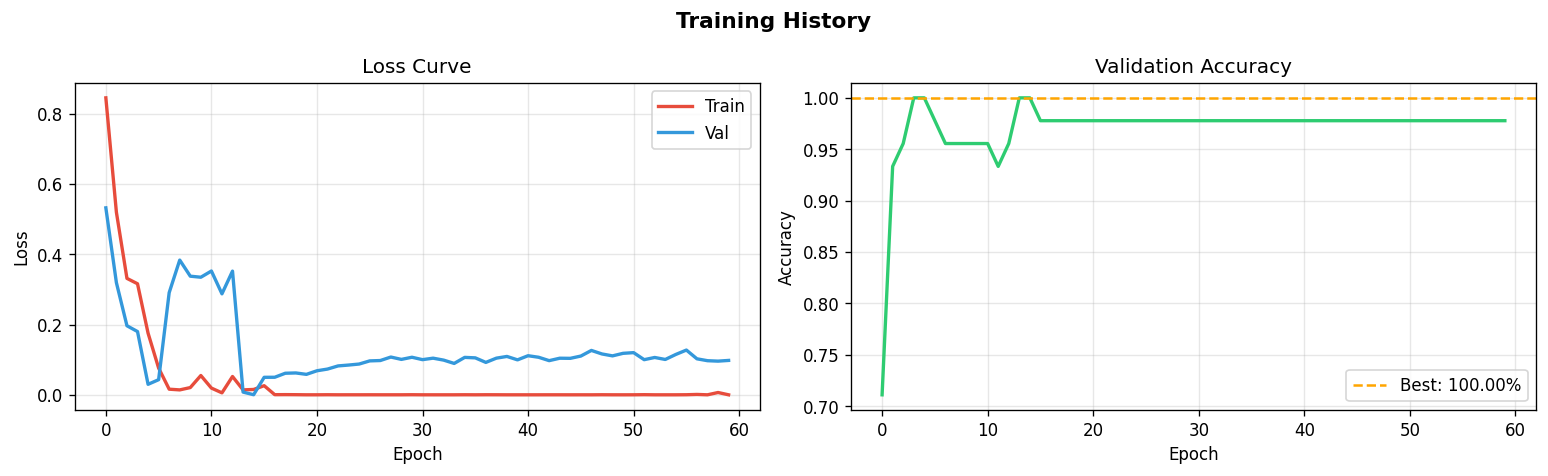

✅ Saved: results/04_training_history.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
fig.suptitle("Training History", fontsize=13, fontweight="bold")

axes[0].plot(history["train_loss"], color="#E74C3C", linewidth=2, label="Train")
axes[0].plot(history["val_loss"],   color="#3498DB", linewidth=2, label="Val")
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["val_acc"], color="#2ECC71", linewidth=2)
axes[1].axhline(best_val_acc, color="orange", linestyle="--",
                label=f"Best: {best_val_acc:.2%}")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/04_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: results/04_training_history.png")

In [ ]:
# Mutual Information measures statistical dependence between each feature
# and the stress label. Higher MI = feature carries more unique information
# about stress state. Answers: WHICH signals most reliably detect stress?

xai_code = '''
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import os

def compute_feature_importance(X, y, feature_names, results_dir="results/"):
    os.makedirs(results_dir, exist_ok=True)
    mi      = mutual_info_classif(X, y, random_state=42)
    idx     = np.argsort(mi)[::-1]
    return mi[idx], [feature_names[i] for i in idx], idx
'''
with open("explainability/shap_explainer.py", "w", encoding="utf-8") as f:
    f.write(xai_code)

import explainability.shap_explainer
importlib.reload(explainability.shap_explainer)
from explainability.shap_explainer import compute_feature_importance

scores, sorted_names, sorted_idx = compute_feature_importance(
    X_flat, y, all_feature_names)

thermal_total  = sum(scores[list(sorted_idx).index(i)] for i in range(24))
physio_total   = sum(scores[list(sorted_idx).index(i)] for i in range(24,39))
temporal_total = sum(scores[list(sorted_idx).index(i)] for i in range(39,48))
grand_total    = thermal_total + physio_total + temporal_total + 1e-8
mod_pcts       = [thermal_total/grand_total*100,
                  physio_total/grand_total*100,
                  temporal_total/grand_total*100]
modalities     = ["Thermal","Physiological","Temporal"]
mod_colors     = ["#E74C3C","#3498DB","#2ECC71"]

print("Top 15 Features by Mutual Information:\n")
print(f"  {'Rank':<5} {'Feature':<35} {'MI Score':>8}")
print(f"  {'-'*50}")
for i,(n,s) in enumerate(zip(sorted_names[:15], scores[:15]),1):
    print(f"  {i:<5} {n:<35} {s:>8.4f}")

print(f"\nModality Contributions:")
for m,p in zip(modalities, mod_pcts):
    bar = "█" * int(p/2)
    print(f"  {m:<18} {bar:<25} {p:.1f}%")

In [ ]:
def get_color(name):
    if name in all_feature_names[:24]:   return "#E74C3C"
    elif name in all_feature_names[24:39]: return "#3498DB"
    else:                                  return "#2ECC71"

top_k = 15
fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle("XAI — Feature Importance Analysis", fontsize=13, fontweight="bold")

# Bar chart — top features
colors = [get_color(n) for n in sorted_names[:top_k]]
axes[0].barh(range(top_k), scores[:top_k][::-1],
             color=colors[::-1], edgecolor="black", linewidth=0.6)
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(sorted_names[:top_k][::-1], fontsize=9)
axes[0].set_xlabel("Mutual Information Score", fontsize=11)
axes[0].set_title(f"Top {top_k} Features", fontsize=11)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor="#E74C3C", label="Thermal"),
    Patch(facecolor="#3498DB", label="Physiological"),
    Patch(facecolor="#2ECC71", label="Temporal")], fontsize=9)

# Pie chart — modality contribution
axes[1].pie(mod_pcts, labels=modalities, colors=mod_colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Modality Contribution", fontsize=11)

plt.tight_layout()
plt.savefig("results/05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: results/05_feature_importance.png")

In [ ]:
import numpy as np

risk_data = []
for session in dataset:
    feats, names = extract_temporal_features(session)
    risk_data.append({
        "id":       session["participant_id"],
        "risk":     float(feats[names.index("hormonal_risk_index")]),
        "pf":       session.get("participant_factor", 1.0),
        "stress_hr": session["phases"]["stress"]["heart_rate"].mean(),
        "base_hr":   session["phases"]["baseline"]["heart_rate"].mean(),
    })

risk_data.sort(key=lambda x: x["risk"], reverse=True)
risks          = [d["risk"] for d in risk_data]
mean_risk      = np.mean(risks)
high_threshold = np.percentile(risks, 80)
low_threshold  = np.percentile(risks, 20)
high_count = sum(1 for r in risks if r >= high_threshold)
mid_count  = sum(1 for r in risks if low_threshold <= r < high_threshold)
low_count  = sum(1 for r in risks if r < low_threshold)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Hormonal Dysregulation Risk — All 25 Participants",
             fontsize=13, fontweight="bold")

bar_colors = ["#E74C3C" if r>=high_threshold
              else "#F39C12" if r>=mean_risk
              else "#2ECC71" for r in risks]
axes[0].bar(range(len(risks)), risks, color=bar_colors,
            edgecolor="black", linewidth=0.5)
axes[0].axhline(high_threshold, color="#C0392B", linestyle="--",
                linewidth=1.5, label=f"High risk ({high_threshold:.2f})")
axes[0].axhline(mean_risk, color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean ({mean_risk:.2f})")
axes[0].set_xlabel("Participants (sorted by risk)", fontsize=11)
axes[0].set_ylabel("Hormonal Risk Index", fontsize=11)
axes[0].set_title("Risk Score Distribution", fontsize=11)
axes[0].legend(fontsize=9)

axes[1].pie([high_count, mid_count, low_count],
            labels=["High Risk","Medium Risk","Low Risk"],
            colors=["#E74C3C","#F39C12","#2ECC71"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Risk Categories", fontsize=11)

plt.tight_layout()
plt.savefig("results/06_hormonal_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nRisk Summary:")
print(f"  High risk  (top 20%)    : {high_count} participants")
print(f"  Medium risk             : {mid_count} participants")
print(f"  Low risk   (bottom 20%) : {low_count} participants")
print(f"  Top 3 highest risk IDs  : {[d['id'] for d in risk_data[:3]]}")

In [ ]:
attn_code = '''
import numpy as np, torch, os
import matplotlib.pyplot as plt

def extract_attention_weights(model, X_tensor, device="cpu"):
    model.eval()
    with torch.no_grad():
        logits, risk, attn = model(X_tensor.to(device))
        preds = logits.argmax(-1).cpu().numpy()
    return attn.cpu().numpy(), risk.cpu().numpy(), preds

def plot_attention_heatmap(attn_weights, predictions,
                            results_dir="results/", save=True):
    os.makedirs(results_dir, exist_ok=True)
    class_names = ["Baseline","Stress","Recovery"]
    colors      = ["#2ECC71","#E74C3C","#3498DB"]
    fig, axes   = plt.subplots(3,1,figsize=(13,8))
    fig.suptitle("Attention Weights — What the Model Focuses On",
                 fontsize=13, fontweight="bold")
    for ci in range(3):
        mask = predictions == ci
        ax   = axes[ci]
        if mask.sum() == 0:
            ax.set_title(f"{class_names[ci]} — no samples"); continue
        avg = attn_weights[mask].mean(axis=0)
        ax.plot(avg, color=colors[ci], linewidth=2.5)
        ax.fill_between(range(len(avg)), avg, alpha=0.3, color=colors[ci])
        pk = np.argmax(avg)
        ax.axvline(pk, color="black", linestyle="--", linewidth=1.2)
        ax.text(pk+0.5, avg[pk], f"Peak@t={pk}", fontsize=9)
        ax.set_title(f"{class_names[ci]} Phase (n={mask.sum()})",
                     fontsize=11, fontweight="bold", color=colors[ci])
        ax.set_ylabel("Attention Weight"); ax.grid(alpha=0.3)
    axes[2].set_xlabel("Time Step")
    plt.tight_layout()
    if save:
        fig.savefig(os.path.join(results_dir,"07_attention.png"),
                    dpi=150, bbox_inches="tight")
    return fig
'''
with open("explainability/attention_viz.py", "w", encoding="utf-8") as f:
    f.write(attn_code)

import explainability.attention_viz
importlib.reload(explainability.attention_viz)
from explainability.attention_viz import extract_attention_weights, plot_attention_heatmap

X_tensor = torch.tensor(X_seq, dtype=torch.float32)
attn_w, risk_scores, preds = extract_attention_weights(model, X_tensor)

fig = plot_attention_heatmap(attn_w, preds)
plt.show()
print("✅ Saved: results/07_attention.png")